In [101]:
import pandas as pd

In [102]:
df= pd.read_csv("/content/lka-rainfall-adm2-full.csv")

In [103]:
df

,date,adm2_id,ADM2_PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
0,#date,#adm2+id,#adm2+code,#indicator+n_pixels+num,#indicator+rfh+num,#indicator+rfh_avg+num,#indicator+r1h+num,#indicator+r1h_avg+num,#indicator+r3h+num,#indicator+r3h_avg+num,#indicator+rfq+pct,#indicator+r1q+pct,#indicator+r3q+pct,#status
1,1/1/1981,25840,LK45,41,51.9756,38.2098,NaN,NaN,NaN,NaN,131.8582,NaN,NaN,final
2,1/11/1981,25840,LK45,41,11.1707,24.2545,NaN,NaN,NaN,NaN,55.2761,NaN,NaN,final
3,1/21/1981,25840,LK45,41,2.7073,26.0366,65.8537,88.5008,NaN,NaN,24.833,77.0082,NaN,final
4,2/1/1981,25840,LK45,41,14.561,16.4992,28.439,66.7902,NaN,NaN,90.9847,50.0572,NaN,final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39846,2/21/2025,25843,LK43,65,41.0154,9.4374,46.6308,42.3841,393.4923,411.2256,318.7227,108.1068,95.7901,final
39847,3/1/2025,25843,LK43,65,21.8154,17.4241,65.7692,38.3954,402.9231,339.5677,119.5829,156.5629,118.1239,final
39848,3/11/2025,25843,LK43,65,23.8923,14.9631,86.7231,41.8246,368.9538,262.6415,144.7287,186.6354,138.9934,final
39849,3/21/2025,25843,LK43,65,2.8769,17.8559,48.5846,50.2431,331.7231,204.3503,34.4634,97.247,159.4228,final


In [104]:
df.drop(index=0, inplace=True)

In [105]:
df.shape

(39850, 14)

In [106]:
# datatypes
df.dtypes

,0
date,object
adm2_id,object
ADM2_PCODE,object
n_pixels,object
rfh,object
rfh_avg,object
r1h,object
r1h_avg,object
r3h,object
r3h_avg,object


In [107]:
# Change the data type to float
df["rfh"] = pd.to_numeric(df["rfh"], errors='coerce')
df['rfh_avg'] = pd.to_numeric(df['rfh_avg'], errors='coerce')
df['r1h'] = pd.to_numeric(df['r1h'], errors='coerce')
df['r1h_avg'] = pd.to_numeric(df['r1h_avg'], errors='coerce')
df['r3h'] = pd.to_numeric(df['r3h'], errors='coerce')
df['r3h_avg'] = pd.to_numeric(df['r3h_avg'], errors='coerce')
df['rfq'] = pd.to_numeric(df['rfq'], errors='coerce')
df['r1q'] = pd.to_numeric(df['r1q'], errors='coerce')
df['r3q'] = pd.to_numeric(df['r3q'], errors='coerce')

# change n_pixels to int
df['n_pixels'] = df['n_pixels'].astype(int)

# Change date to datetime
df['date'] = pd.to_datetime(df['date'])

In [108]:
df.dtypes

,0
date,datetime64[ns]
adm2_id,object
ADM2_PCODE,object
n_pixels,int64
rfh,float64
rfh_avg,float64
r1h,float64
r1h_avg,float64
r3h,float64
r3h_avg,float64


In [109]:
df.isnull().sum()

,0
date,0
adm2_id,0
ADM2_PCODE,0
n_pixels,0
rfh,0
rfh_avg,0
r1h,50
r1h_avg,50
r3h,200
r3h_avg,200


In [110]:
df[df.isnull().any(axis=1)]

,date,adm2_id,ADM2_PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
1,1981-01-01,25840,LK45,41,51.9756,38.2098,NaN,NaN,NaN,NaN,131.8582,NaN,NaN,final
2,1981-01-11,25840,LK45,41,11.1707,24.2545,NaN,NaN,NaN,NaN,55.2761,NaN,NaN,final
3,1981-01-21,25840,LK45,41,2.7073,26.0366,65.8537,88.5008,NaN,NaN,24.8330,77.0082,NaN,final
4,1981-02-01,25840,LK45,41,14.5610,16.4992,28.4390,66.7902,NaN,NaN,90.9847,50.0572,NaN,final
5,1981-02-11,25840,LK45,41,2.0000,10.7528,19.2683,53.2886,NaN,NaN,44.4364,46.2457,NaN,final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38260,1981-02-01,25843,LK43,65,26.0000,21.4128,38.6154,85.0610,NaN,NaN,117.3672,51.1412,NaN,final
38261,1981-02-11,25843,LK43,65,2.0154,11.5338,30.5077,63.5241,NaN,NaN,42.4304,55.0944,NaN,final
38262,1981-02-21,25843,LK43,65,2.2769,9.4374,30.2923,42.3841,NaN,NaN,50.4032,76.9171,NaN,final
38263,1981-03-01,25843,LK43,65,2.6462,17.4241,6.9385,38.3954,NaN,NaN,34.0979,35.0002,NaN,final


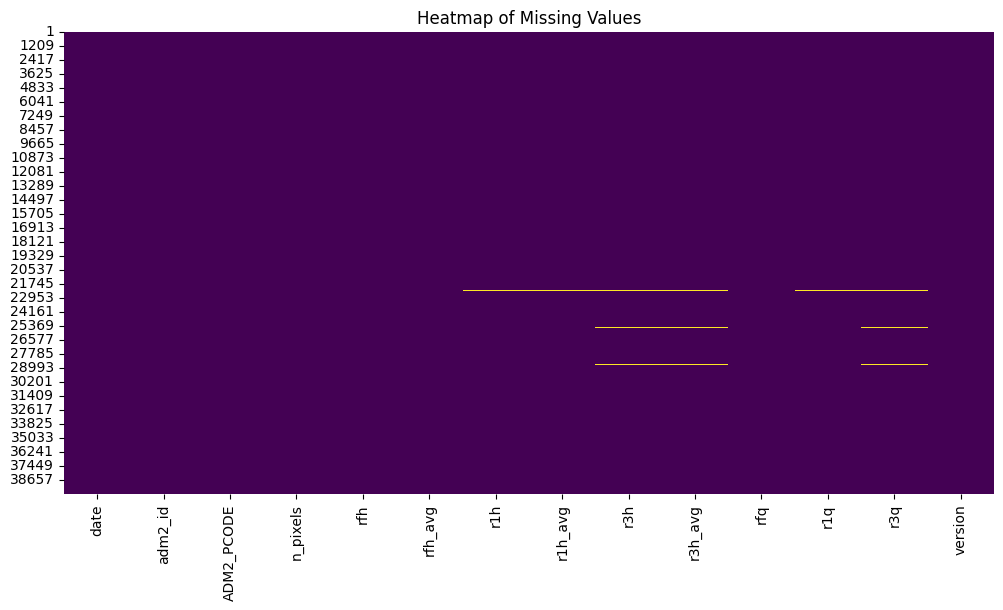

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()


In [112]:
# Check for missing values at the start
missing_start = df.head(df.isnull().any(axis=1).idxmax() + 1).isnull().any(axis=1).all()

# Check for missing values at the end
missing_end = df.tail(len(df) - df.isnull().any(axis=1).idxmin()).isnull().any(axis=1).all()

# Check if missing values are only at the start and end
only_start_end = missing_start and missing_end and not df.iloc[df.isnull().any(axis=1).idxmax() + 1 : df.isnull().any(axis=1).idxmin() -1].isnull().any(axis=1).any()

print(f"Missing values only at start and end: {only_start_end}")

Missing values only at start and end: False


In [121]:
# Unique ADM2_PC0DEs
print(df['ADM2_PCODE'].unique())
print(df['ADM2_PCODE'].nunique())

['LK45' 'LK51' 'LK91' 'LK31' 'LK33' 'LK32' 'LK81' 'LK82' 'LK11' 'LK12'
 'LK13' 'LK52' 'LK21' 'LK44' 'LK42' 'LK22' 'LK41' 'LK62' 'LK61' 'LK72'
 'LK71' 'LK53' 'LK23' 'LK92' 'LK43']
25


In [115]:
# Missing values by district
missing_values_by_adm2_pcode = df.groupby('ADM2_PCODE').apply(lambda x: x.isnull().sum())

print(missing_values_by_adm2_pcode)

            date  adm2_id  ADM2_PCODE  n_pixels  rfh  rfh_avg  r1h  r1h_avg  \
ADM2_PCODE                                                                    
LK11           0        0           0         0    0        0    2        2   
LK12           0        0           0         0    0        0    2        2   
LK13           0        0           0         0    0        0    2        2   
LK21           0        0           0         0    0        0    2        2   
LK22           0        0           0         0    0        0    2        2   
LK23           0        0           0         0    0        0    2        2   
LK31           0        0           0         0    0        0    2        2   
LK32           0        0           0         0    0        0    2        2   
LK33           0        0           0         0    0        0    2        2   
LK41           0        0           0         0    0        0    2        2   
LK42           0        0           0         0    0

<ipython-input-115-4413aed35a72>:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_values_by_adm2_pcode = df.groupby('ADM2_PCODE').apply(lambda x: x.isnull().sum())


In [116]:
# Create day, month and year features
df.insert(df.columns.get_loc('date') + 1, 'Year', df['date'].dt.year)
df.insert(df.columns.get_loc('date') + 2, 'Month', df['date'].dt.month)
df.insert(df.columns.get_loc('date') + 3, 'Day', df['date'].dt.day)

In [117]:
# Month names dictionary
month_dict = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

# Rename the 'Month' column using the dictionary
df['Month'] = df['Month'].map(month_dict)

In [118]:
# Disctionary of Districts
district_mapping = {
    'LK52': 'Ampara',
    'LK71': 'Anuradhapura',
    'LK81': 'Badulla',
    'LK51': 'Batticaloa',
    'LK11': 'Colombo',
    'LK31': 'Galle',
    'LK12': 'Gampaha',
    'LK33': 'Hambantota',
    'LK41': 'Jaffna',
    'LK13': 'Kalutara',
    'LK21': 'Kandy',
    'LK92': 'Kegalle',
    'LK45': 'Kilinochchi',
    'LK61': 'Kurunegala',
    'LK42': 'Mannar',
    'LK22': 'Matale',
    'LK32': 'Matara',
    'LK82': 'Monaragala',
    'LK44': 'Mullaitivu',
    'LK23': 'Nuwara Eliya',
    'LK72': 'Polonnaruwa',
    'LK62': 'Puttalam',
    'LK91': 'Ratnapura',
    'LK53': 'Trincomalee',
    'LK43': 'Vavuniya'
}

# Get the index of the 'ADM2_PCODE' column
adm2_pcode_index = df.columns.get_loc('ADM2_PCODE')

# Insert the 'districts' column at the index + 1
df.insert(adm2_pcode_index + 1, 'districts', df['ADM2_PCODE'].map(district_mapping))

In [119]:
df

,date,Year,Month,Day,adm2_id,ADM2_PCODE,districts,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
1,1981-01-01,1981,January,1,25840,LK45,Kilinochchi,41,51.9756,38.2098,NaN,NaN,NaN,NaN,131.8582,NaN,NaN,final
2,1981-01-11,1981,January,11,25840,LK45,Kilinochchi,41,11.1707,24.2545,NaN,NaN,NaN,NaN,55.2761,NaN,NaN,final
3,1981-01-21,1981,January,21,25840,LK45,Kilinochchi,41,2.7073,26.0366,65.8537,88.5008,NaN,NaN,24.8330,77.0082,NaN,final
4,1981-02-01,1981,February,1,25840,LK45,Kilinochchi,41,14.5610,16.4992,28.4390,66.7902,NaN,NaN,90.9847,50.0572,NaN,final
5,1981-02-11,1981,February,11,25840,LK45,Kilinochchi,41,2.0000,10.7528,19.2683,53.2886,NaN,NaN,44.4364,46.2457,NaN,final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39846,2025-02-21,2025,February,21,25843,LK43,Vavuniya,65,41.0154,9.4374,46.6308,42.3841,393.4923,411.2256,318.7227,108.1068,95.7901,final
39847,2025-03-01,2025,March,1,25843,LK43,Vavuniya,65,21.8154,17.4241,65.7692,38.3954,402.9231,339.5677,119.5829,156.5629,118.1239,final
39848,2025-03-11,2025,March,11,25843,LK43,Vavuniya,65,23.8923,14.9631,86.7231,41.8246,368.9538,262.6415,144.7287,186.6354,138.9934,final
39849,2025-03-21,2025,March,21,25843,LK43,Vavuniya,65,2.8769,17.8559,48.5846,50.2431,331.7231,204.3503,34.4634,97.2470,159.4228,final


In [122]:
# Unique Months
print(df['Month'].unique())
print(df['Month'].nunique())

['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']
12


In [123]:
# Unique Years
print(df['Year'].unique())
print(df['Year'].nunique())

[1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994
 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008
 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022
 2023 2024 2025]
45


In [125]:
# Unique versions
print(df['version'].unique())
print(df['version'].nunique())

['final' 'prelim']
2


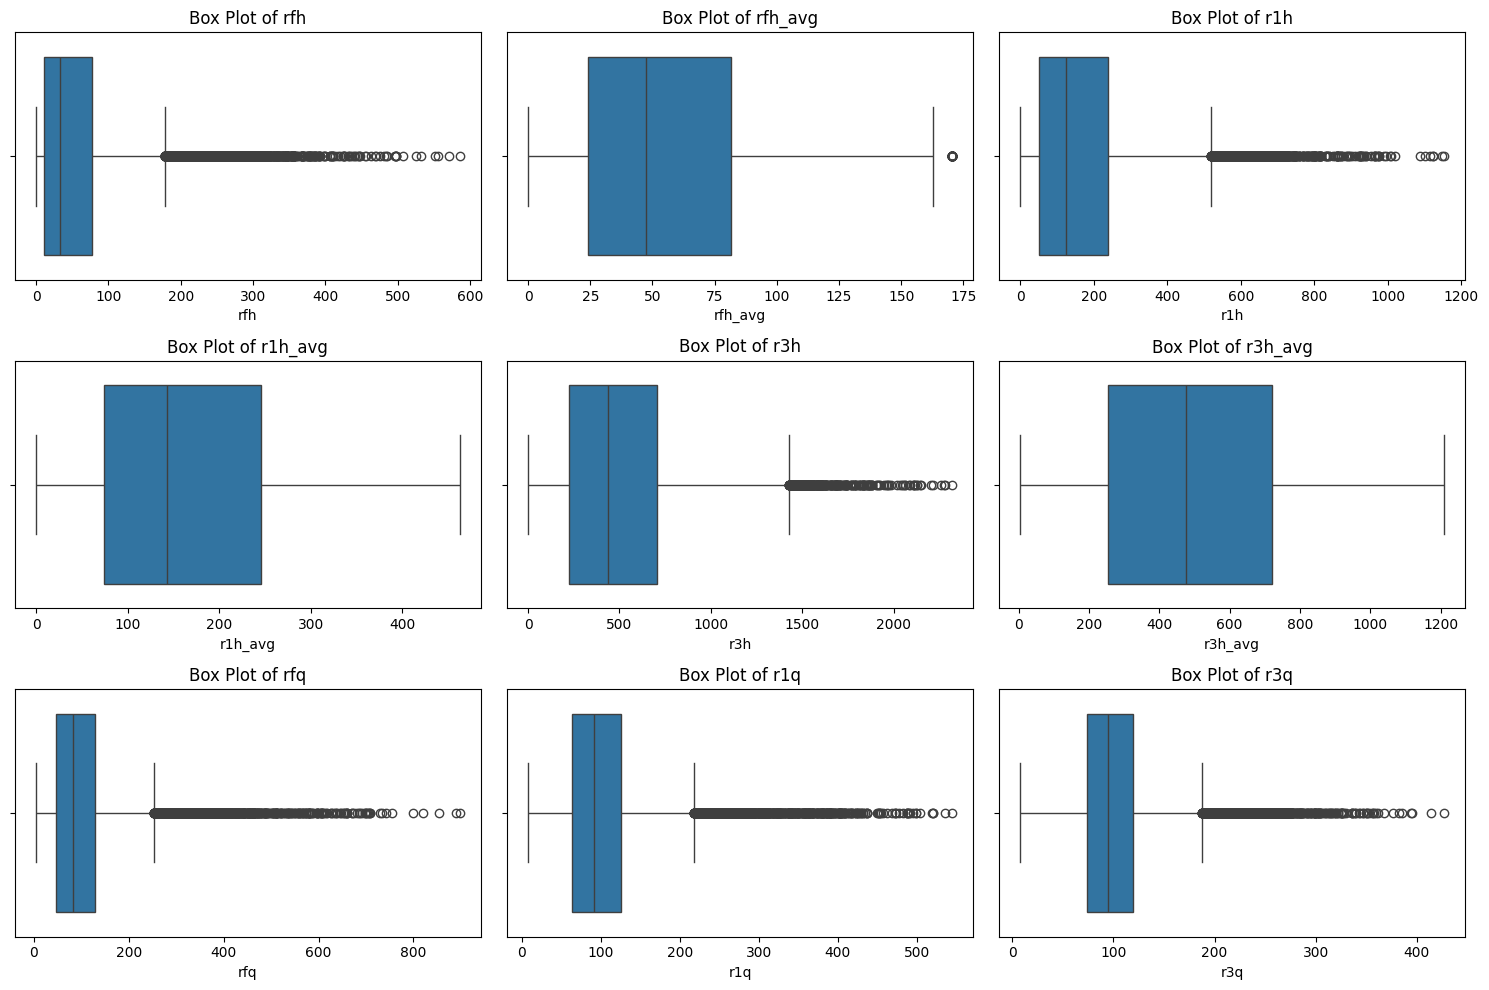

In [127]:
# Select the features for the box plots
features = ['rfh', 'rfh_avg', 'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq', 'r1q', 'r3q']

# Create a figure and subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 10))  # 3 rows, 3 columns

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate through the features and create box plots
for i, feature in enumerate(features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(f'Box Plot of {feature}')
    axes[i].set_xlabel(feature)

# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

In [128]:
df

,date,Year,Month,Day,adm2_id,ADM2_PCODE,districts,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version
1,1981-01-01,1981,January,1,25840,LK45,Kilinochchi,41,51.9756,38.2098,NaN,NaN,NaN,NaN,131.8582,NaN,NaN,final
2,1981-01-11,1981,January,11,25840,LK45,Kilinochchi,41,11.1707,24.2545,NaN,NaN,NaN,NaN,55.2761,NaN,NaN,final
3,1981-01-21,1981,January,21,25840,LK45,Kilinochchi,41,2.7073,26.0366,65.8537,88.5008,NaN,NaN,24.8330,77.0082,NaN,final
4,1981-02-01,1981,February,1,25840,LK45,Kilinochchi,41,14.5610,16.4992,28.4390,66.7902,NaN,NaN,90.9847,50.0572,NaN,final
5,1981-02-11,1981,February,11,25840,LK45,Kilinochchi,41,2.0000,10.7528,19.2683,53.2886,NaN,NaN,44.4364,46.2457,NaN,final
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39846,2025-02-21,2025,February,21,25843,LK43,Vavuniya,65,41.0154,9.4374,46.6308,42.3841,393.4923,411.2256,318.7227,108.1068,95.7901,final
39847,2025-03-01,2025,March,1,25843,LK43,Vavuniya,65,21.8154,17.4241,65.7692,38.3954,402.9231,339.5677,119.5829,156.5629,118.1239,final
39848,2025-03-11,2025,March,11,25843,LK43,Vavuniya,65,23.8923,14.9631,86.7231,41.8246,368.9538,262.6415,144.7287,186.6354,138.9934,final
39849,2025-03-21,2025,March,21,25843,LK43,Vavuniya,65,2.8769,17.8559,48.5846,50.2431,331.7231,204.3503,34.4634,97.2470,159.4228,final


In [129]:
# Export the processed dataset
df.to_csv('preprocessed_dataset.csv', index=False)